# PyTorch 手写数字识别（MNIST）

本 Notebook 使用 PyTorch 完成手写数字识别任务，包含：数据准备、模型定义、训练、评估、保存与推理展示。

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', device)

PyTorch version: 2.7.0+cu128
Device: cuda


In [ ]:
# 如果环境缺少依赖，取消下一行注释后执行
# !pip install torch torchvision matplotlib

DATA_ROOT = './MNIST_Data_torch'
BATCH_SIZE = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Train samples:', len(train_dataset))
print('Test samples:', len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.23MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 145kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 830kB/s] 
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Train samples: 60000
Test samples: 10000


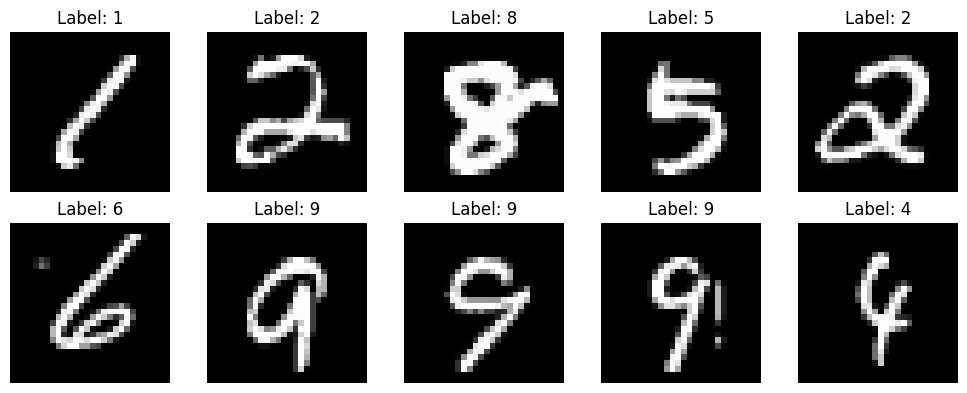

In [3]:
# 可视化部分训练样本
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = images[i].squeeze().numpy()
    img = img * 0.5 + 0.5  # 反归一化，便于显示
    plt.imshow(img, cmap='gray')
    plt.title(f'Label: {labels[i].item()}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class MLP(nn.Module):
    """
    多层：
    Input(28*28) -> Dense(512) -> ReLU -> Dense(512) -> ReLU -> Dense(512) -> ReLU -> Dense(10)
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

print(model)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=512, bias=True)
    (6): ReLU()
    (7): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [5]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = loss_fn(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    acc = correct / total
    return avg_loss, acc

EPOCHS = 3
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
    print(f'Epoch {epoch + 1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc * 100:.2f}%')

Epoch 1/3 | Train Loss: 1.2447 | Test Loss: 0.4564 | Test Acc: 86.73%
Epoch 2/3 | Train Loss: 0.3888 | Test Loss: 0.3316 | Test Acc: 90.47%
Epoch 3/3 | Train Loss: 0.3177 | Test Loss: 0.2906 | Test Acc: 91.14%


In [6]:
MODEL_PATH = 'model_torch.pth'
torch.save(model.state_dict(), MODEL_PATH)
print(f'Saved model to {MODEL_PATH}')

# 重新加载模型参数验证保存有效
loaded_model = MLP().to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
print('Model loaded successfully.')

Saved model to model_torch.pth
Model loaded successfully.


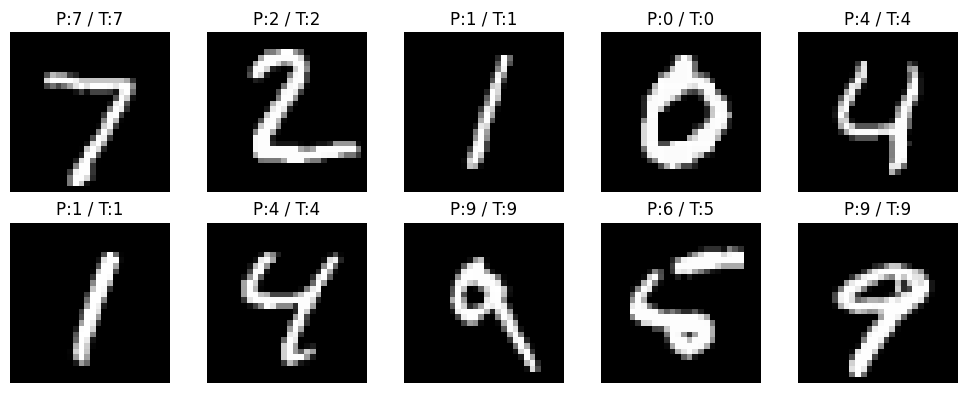

In [7]:
@torch.no_grad()
def show_predictions(model, dataloader, device, n=10):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)
    logits = model(images)
    preds = logits.argmax(dim=1)

    plt.figure(figsize=(10, 4))
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        img = images[i].detach().cpu().squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap='gray')
        plt.title(f'P:{preds[i].item()} / T:{labels[i].item()}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(loaded_model, test_loader, device, n=10)